lsgo

#1 spectral diff 1d

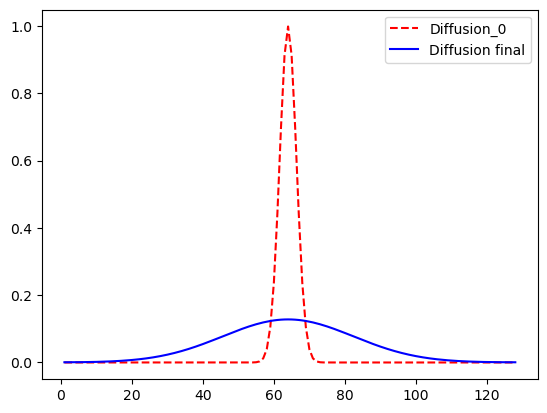

In [131]:
import numpy as np
import matplotlib.pyplot as plt
L = 128        # System size
N = 30000       # Total no. of iterations
delt = 0.1     # temporal step size/resolution
delx = 0.3     # spatial step size/resolution
D = 0.005      # Diffusion constant
c = np.zeros(L)
c0 = np.zeros(L)
K = (2 * np.pi / (L * delx)) * np.concatenate((np.arange(0, L//2), np.arange(-L//2, 0)))

x = np.arange(1, L + 1)
c0 = np.exp(-((x - L/2) * delx / 1)**2)
c = c0.copy()
cc = np.fft.fft(c)
cT = np.zeros((L, N))

for i in range(N):
    for p in range(L):
        cc[p] = cc[p] - D * delt * (K[p]**2) * cc[p]
    cT[:, i] = np.real(np.fft.ifft(cc))
# Neumann_par = D * delt / (delx * delx)
import matplotlib.pyplot as plt

x_plot = x * delx
plt.figure()
plt.plot(x, cT[:,0], 'r--', label = 'Diffusion_0')
plt.plot(x, cT[:,-1], 'b' , label = 'Diffusion final')
plt.legend()
plt.show()

#2 spectral advection   

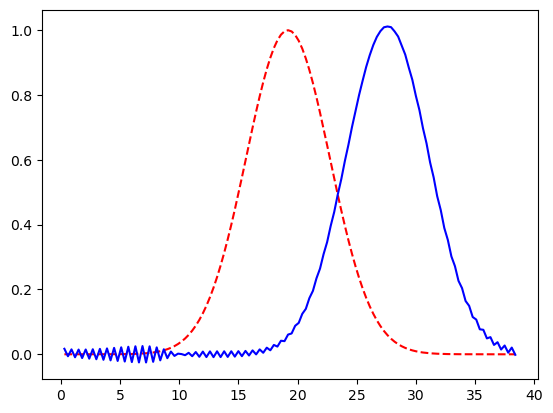

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
L = 128        # System size
N = 3000       # Total no. of iterations
delt = 0.01    # temporal step size (smaller than diffusion for stability)
delx = 0.3     # spatial step size
y = np.zeros(L)
K = (2 * np.pi / (L * delx)) * np.concatenate((
    np.arange(0, L//2),
    np.arange(-L//2, 0)
))
x = np.arange(1, L + 1)
y0 = np.exp(-((x - L/2) * delx / 5)**2)
y = y0.copy()
yy = np.fft.fft(y)
yT = np.zeros((L, N))

for i in range(N):
    for p in range(L):
        yy[p] = yy[p] + delt * (1j * K[p]) * yy[p]

    yT[:, i] = np.real(np.fft.ifft(yy))


x_plot = x * delx
plt.figure()
plt.plot(x_plot, yT[:,0],'r--', label = "Adv_0")
plt.plot(x_plot, yT[:,-1],'b', label = "Adv_final")
plt.show()

#3     Fockker-Planck

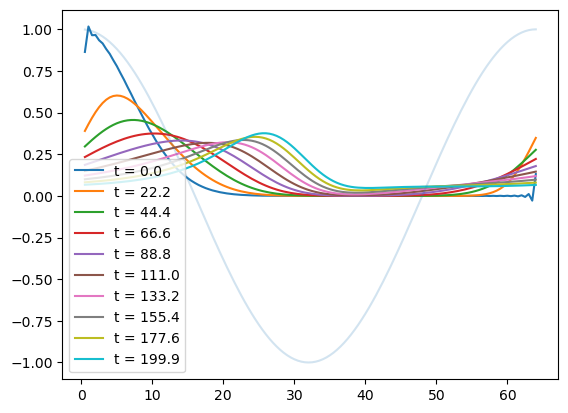

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L, N, D, delt, delx =  128, 2000, 0.2, 0.1, 0.5

x = np.arange(1,L+1)

c0 = np.exp((- ((x)*delx)**2)/100)
c = c0.copy()
cc = np.fft.fft(c)F(Uc)

U = - np.cos(2*np.pi / L*(x-L/2))
Up =(2*np.pi / (L*delx)) * np.sin(2*np.pi / L * (x-L/2))

K = (2*np.pi / (L*delx))* np.concatenate((np.arange(0,L//2),np.arange(-L//2, 0)))

cT = np.zeros((L,N))

for i in range(N):
    rho   = Up*c
    crho = np.fft.fft(rho)

    cc=cc+delt*(-D*(K**2)*cc+1j*K*crho)
    c = np.real(np.fft.ifft(cc))
    cT[:,i]=c

x_plot = x*delx

plt.figure()
idx = np.linspace(0,N-1, 10, dtype= int)

for i in idx:
    plt.plot(x_plot, cT[:, i], label=f"t = {i*delt:.1f}")

plt.plot(x_plot, U, alpha = 0.2)

plt.legend()
plt.show()


/tmp/ipykernel_8703/345724397.py:19: RuntimeWarning: overflow encountered in multiply
  drho_hat_dt=-D*kk**2*rho_hat+1j*kk*drift_term
/tmp/ipykernel_8703/345724397.py:20: RuntimeWarning: invalid value encountered in multiply
  rho_hat_new=rho_hat+dt*drho_hat_dt
/tmp/ipykernel_8703/345724397.py:18: RuntimeWarning: invalid value encountered in multiply
  drift_term=np.fft.fft(rho*du_dx)
/tmp/ipykernel_8703/345724397.py:19: RuntimeWarning: invalid value encountered in multiply
  drho_hat_dt=-D*kk**2*rho_hat+1j*kk*drift_term


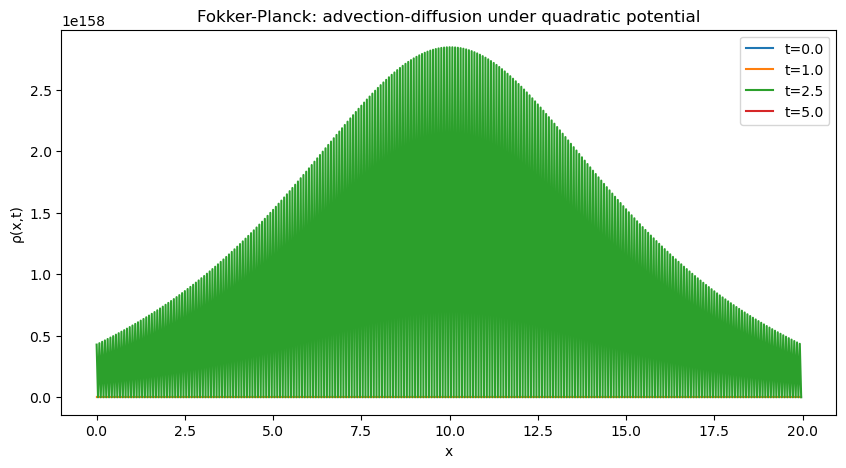

In [51]:
import numpy as np
import matplotlib.pyplot as plt
def solve_fokker_planck(L=20,N=512,dt=0.01,t_final=5.0,D=0.15,k=0.01):
    x=np.linspace(0,L,N,endpoint=False)
    dx=x[1]-x[0]
    kk=2*np.pi*np.fft.fftfreq(N,dx)
    sigma0=0.5
    x_center=L/2
    rho=np.exp(-(x-x_center)**2/(2*sigma0**2))
    rho/=np.sum(rho)*dxF(Uc)
    u=0.5*k*(x-L/2)**2
    du_dx=k*(x-L/2)
    du_hat=np.fft.fft(du_dx)
    times=np.arange(0,t_final+dt,dt)
    results=[rho.copy()]
    for t_current in times[1:]:
        rho_hat=np.fft.fft(rho)
        drift_term=np.fft.fft(rho*du_dx)
        drho_hat_dt=-D*kk**2*rho_hat+1j*kk*drift_term
        rho_hat_new=rho_hat+dt*drho_hat_dt
        rho=np.real(np.fft.ifft(rho_hat_new))
        rho=np.maximum(rho,0)
        rho/=np.sum(rho)*dx
        results.append(rho.copy())
    return x,times,results
x,times,results=solve_fokker_planck()
plt.figure(figsize=(10,5))
for idx in [0,100,250,500]:
    plt.plot(x,results[idx],label=f't={times[idx]:.1f}')
plt.xlabel('x')
plt.ylabel('ρ(x,t)')
plt.title('Fokker-Planck: advection-diffusion under quadratic potential')
plt.legend()
plt.show()

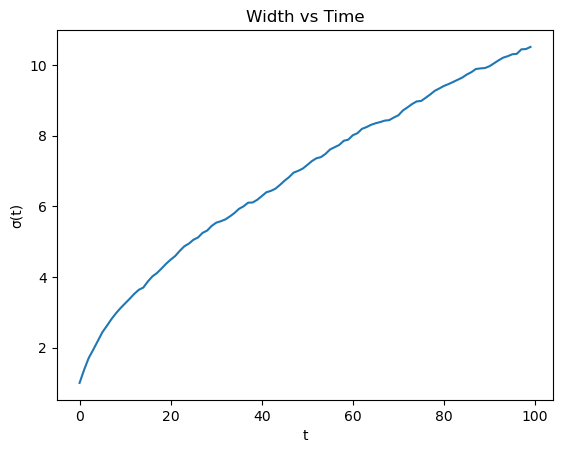

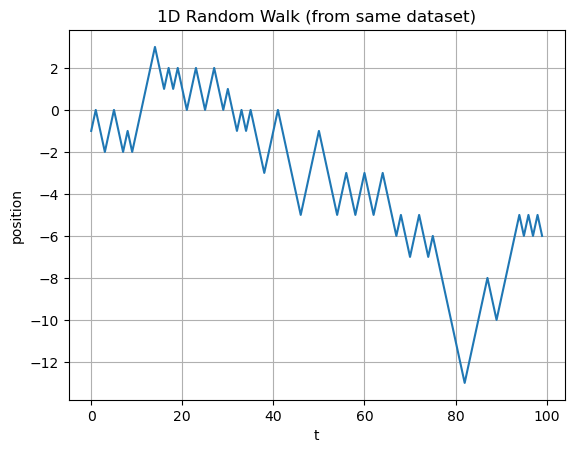

In [ ]:

# y0 = np.zeros(L)
# import numpy as np
import matplotlib.pyplot as plt
n=100
l=1000
L=np.zeros(l)
L_t=[]
for j in range(n):
    for i in range(l):
        r=np.random.random()
        if r<=0.5:
            L[i]+=1
        else:
            L[i]-=1
    L_t.append(L.copy())
def sigma(L_snapshot):
    rho={}
    for pos in L_snapshot:
        rho[pos]=rho.get(pos,0)+1
        # print(rho)
    total=len(L_snapshot)
    sigma2=0
    for x,count in rho.items():
        sigma2+=x**2*(count/total)
    return sigma2**0.5
sigma_t=[]
for i in range(n):
    sigma_t.append(sigma(L_t[i]))
# print(sigma_t)
plt.plot(range(n),sigma_t)
plt.xlabel('t')
plt.ylabel('σ(t)')
plt.title('Width vs Time')
# plt.show()
walk_1d = [snapshot[0] for snapshot in L_t]

plt.figure()

# 1D random walk trajectory
plt.plot(range(n), walk_1d)

plt.xlabel("t")
plt.ylabel("position")
plt.title("1D Random Walk (from same dataset)")
plt.grid()

plt.show()
 

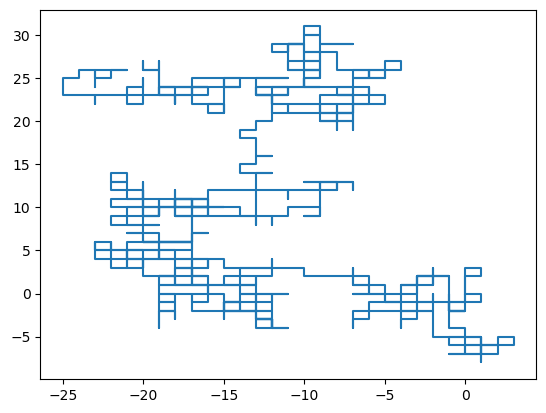

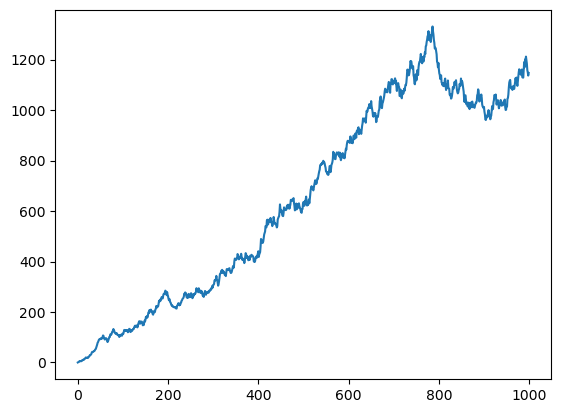

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000
Nre = 10

msd = np.zeros((N,Nre))
X = np.zeros(N)  
Y = np.zeros(N)

for ire in range(Nre):
    x=np.zeros(N)
    y=np.zeros(N)
    for i in range(1,N):
        ro=np.random.rand()
        rd=np.random.rand()
        if ro >= 0.5:
            y[i] = y[i-1]
            x[i] = x[i-1] + (1 if rd >= 0.5 else -1)
        else:
            x[i] = x[i-1]
            y[i] = y[i-1] + (1 if rd >= 0.5 else -1)
    msd[:,ire] = x**2 + y**2
    X = x
    Y = y
msd_mean = np.mean(msd, axis=1)


plt.plot(X[i], Y, label="Trajectory of one random walk")
plt.show()
plt.plot(range(N), msd_mean)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N, Np, L = 3000, 10, 128

x = np.full((N,Np), L//2)
y = np.full((N,Np), L//2)

S = np.zeros(N-1)





visited cells: 112


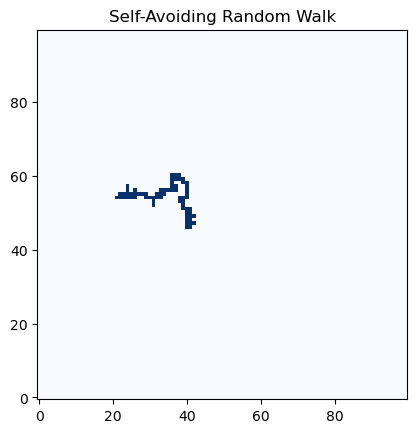

number of walks skipped= 888


In [3]:
import numpy as np
import matplotlib.pyplot as plt
t=1000
l=100
L=np.zeros((l,l))
v=[]
def all_filled(sx,sy,v):
    if [sx,sy+1] in v and [sx+1,sy] in v and [sx-1,sy] in v and [sx,sy-1] in v:
        return True
    else:
        return False
skipped=0
sx=np.random.randint(0,l)
sy=np.random.randint(0,l)
for i in range(t):
    v.append([sx,sy])
    r=np.random.randn()
    nx,ny=sx,sy
    if r < -0.5:          # far negative → move left          
          nx = sx - 1                                           
    elif r < 0:           # mild negative → move down         
        ny = sy - 1                                           
    elif r < 0.5:         # mild positive → move right        
        nx = sx + 1                                           
    else:                 # far positive → move up            
        ny = sy + 1 
    if not (0<=nx<l and 0<=ny<l):
        break
    if all_filled(sx,sy,v):
        break    
    else:
        skipped+=1
        sx=nx
        sy=ny
for point in v:
    L[point[0],point[1]]=1
print("visited cells:", len(v))                               
plt.imshow(L,cmap='Blues',origin='lower')
plt.title('Self-Avoiding Random Walk')
plt.show()
print("number of walks skipped=",t-len(v))

FIND MSD BETA relation. linear search:

Best beta = 0.9773869346733668


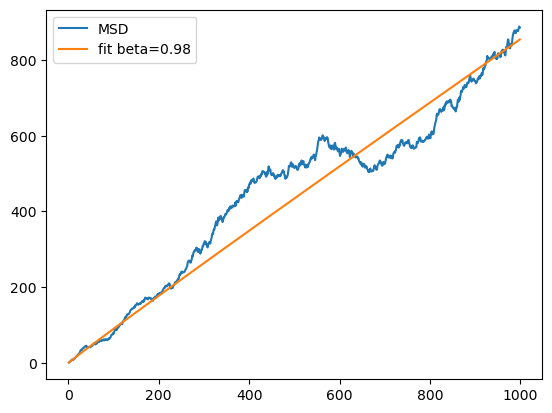

In [53]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000
Nre = 50

msd = np.zeros(N)

for r in range(Nre):
    x = np.zeros(N)
    y = np.zeros(N)

    for t in range(1, N):
        r1 = np.random.rand()
        r2 = np.random.rand()

        if r1 < 0.25:
            x[t] = x[t-1] + 1
            y[t] = y[t-1]
        elif r1 < 0.5:
            x[t] = x[t-1] - 1
            y[t] = y[t-1]
        elif r1 < 0.75:
            x[t] = x[t-1]
            y[t] = y[t-1] + 1
        else:
            x[t] = x[t-1]
            y[t] = y[t-1] - 1

    msd += x**2 + y**2

msd /= Nre

t = np.arange(1, N)

# -----------------------------
# linear search over beta
# -----------------------------
beta_values = np.linspace(0.5, 1.5, 200)

best_beta = 0
best_error = 1e18

for beta in beta_values:
    model = t**beta
    error = np.sum((msd[1:] - model)**2)

    if error < best_error:
        best_error = error
        best_beta = beta

print("Best beta =", best_beta)

# -----------------------------
# plot result
# -----------------------------
plt.plot(t, msd[1:], label="MSD")
plt.plot(t, t**best_beta, label=f"fit beta={best_beta:.2f}")
plt.legend()
plt.show()

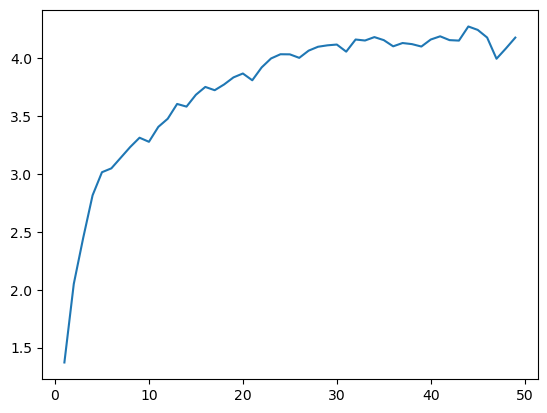

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

N, Np, L = 50, 100, 128

x = np.full((N,Np), L//2)< best_error
y = np.full((N,Np), L//2)

S = np.zeros(N-1)

for i in range(1,N):
    ro = np.random.rand(Np)
    rd = np.random.rand(Np)
    
    c = np.zeros((L,L))
    for j in range(Np):
        x %= L
        y %= L
        if ro[j] >= 0.5:
            y[i,j] = y[i-1,j]
            x[i,j] = x[i-1,j] + (1 if rd[j] >= 0.5 else -1)
        else:
            x[i,j] = x[i-1,j]
            y[i,j] = y[i-1,j] + (1 if rd[j] >= 0.5 else -1)    
        c[x[i,j], y[i,j]] += 1

    p_dis = c / Np
    p_fin = p_dis[p_dis > 0]

    S[i-1] = np.sum( -p_fin * np.log(p_fin) )

plt.plot(range(1,N), S)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L,N,T,J,h = 20, 500, 2.0, 1.0, 0.0
def ice(L,N,T,J,h):
    s = np.random.choice([-1,1], size=(L,L))
    M = []
    for step in range(N):
        for i in range(L):
            for j in range(L):
                nn = (s[(i+1)%L, j]+ s[i,(j+1)%L]+s[(i-1)%L, j]+s[i,(j-1)%L])
                E1 = -J*s[i,j]*nn-h*s[i,j] = term
                E2 = -E1
                dE = E2 - E1
                if dE < 0 or np.random.random() < np.exp(-dE/T):
                    s[i,j] *= -1
        M.append(np.mean(s))    
        mM = np.mean(M)
        Temp = T
    return s, mM, Temp
    
g,mM, Temp = ice(L,N,T,J,h)
print(mM)
print(Temp)


0.8969199999999999
2.0


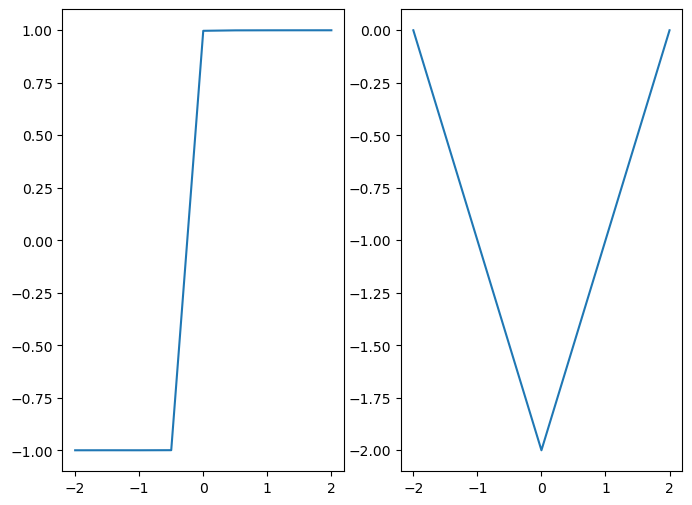

In [20]:
import numpy as np
import matplotlib.pyplot as plt

L,N,T,J = 10 , 2000, 1, 1 

def ice(L,N, T, J):
    mM = []
    h_vals = []
    E = []
    for h in np.arani, j])
    while True:
        r = np.random.randint(0, 4)
        if r == 0:
            dir = np.array([1, 0])
        elif r == 1:
            dir = np.array([-1, 0ge(-2,2.2, 0.5):
        s = np.random.choice([-1,1], size=(L,L)) 
        M = []
        for step in range(N):
            for  i in range(L):
                for j in range(L):
                    nn = (s[(i+1)%L, j] + s[(i-1)%L, j] + s[i, (j+1)%L] + s[i, (j-1)%L])
                    E1 = -J*s[i,j]*nn - h*s[i,j]
                    E2 = -E1
                    dE = E2 - E1
                    H=0
                    if dE<0 or np.random.random()<np.exp(-dE/T):
                        s[i,j]*=-1
                    H += -J*s[i,j]*(s[(i+1)%L,j] + s[i,(j+1)%L]) + h*s[i,j]
            M.append(np.mean(s))      
        mM.append(np.mean(M))
        h_vals.append(h)
        E.append(H)
    return s, mM, h_vals, E

s,Mm, h, Hv = ice(L,N,T,J)

fig, ax = plt.subplots(1,2,figsize=(8,6))
ax[0].plot(h,Mm)
ax[1].plot(h,Hv)

edeeeeeeeeeeeeeeeen  (HAZARD) model 

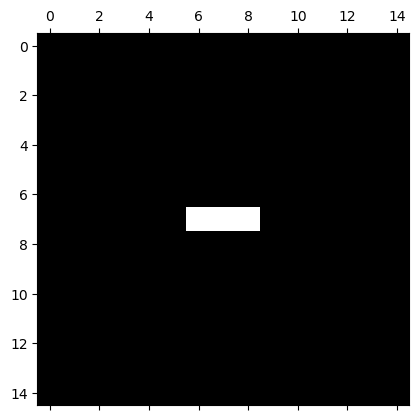

In [60]:
import numpy as np
import matplotlib.pyplot as plt

l = 15
n = 2

clus = np.zeros((l,l))
clus[l//2,l//2] = 1
peri = np.zeros((l,l))

peri[l//2+1,l//2] = 1
peri[l//2-1,l//2] = 1
peri[l//2,l//2+1] = 1
peri[l//2,l//2-1] = 1 #just avoiding modulo for now

for n in range(n):
    # sites = []
    i_idx, j_idx = np.where(peri == 1)
    r = np.random.randint(len(i_idx))
    i, j = i_idx[r], j_idx[r]
    clus[i,j] = 1
    peri[i,j] = 0

    if clus[i+1,j]==0:
        peri[i+1,j]=1
    if clus[i-1,j]==0:
        peri[i-1,j]=1
    if clus[i,j+1]==0:
        peri[i,j+1]=1
    if clus[i,j-1]==0:
        peri[i,j-1]=1
    
plt.matshow(clus, cmap='gray')

DFA #Diff

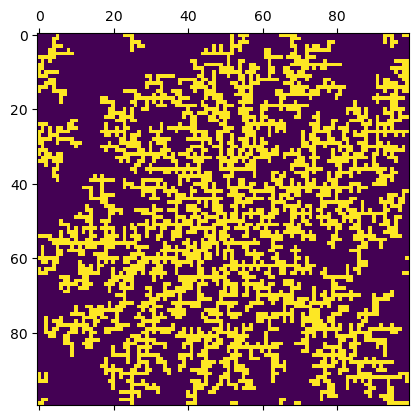

In [43]:
import numpy as np
import matplotlib.pyplot as plt
l,n=100,4000

clus=np.zeros((l,l))
clus[l//2,l//2]=1

for nn in range(n):
    while True:
        x,y=np.random.randint(0,l),np.random.randint(0,l)
        if clus[x,y]==0:
            break
    
    while True:
        ro=np.random.rand()
        rd=np.random.rand()
        if ro<0.5:
            nx = x+(1 if rd>=0.5 else -1)
            ny = y
        else:
            nx = x
            ny = y+(1 if rd>=0.5 else -1)

        nx=nx%l
        ny=ny%l

        if (clus[(nx+1)%l,ny]==1 or clus[(nx-1)%l,ny]==1 or clus[nx,(ny+1)%l]==1 or clus[nx,(ny-1)%l] ==1):
            clus[nx,ny]=1
            break
        else:
            x,y=nx,ny

plt.matshow(clus)